PyTorch Neural Network Classification

Multi-Class Classification: with make_blobs (crossEntropy, softmax)

+Example of Toy Problem as practice (circle): "a problem that's used to try & test things out" with binary cross entropy & ReLU & SGD — commented out

Note: lr typically at 0.001 to be safe but 0.01 good start point

Classification Problem:
- Binary Classification: predict 1 of 2 options
- Multi-Class Classification: predict 1 of many options
- Multi-Label Classification: target can be more than 1 option

Architecture of Classification NN: Hyperparameters:
- Input Layer Features: #of features
- Hidden Layer(s): 1->unlimited #
- Neurons per Hidden Layer: Generally 10-512
- Output Layer Shape: 1 per class
- Hidden Layer Activation: Func for if activate neuron — Many types ~ common ReLU (Recitified Linear Unit) 0 if negative 1 if positive, others: tanh, etc
- Output Activation: Binary: Sigmoid, Multi-Class: Softmax
- Loss Function: Binary: Binary crossentropy, Multi-Class: cross entropy
- Optimizer: SGD, Adam
Note: Ctrl + "/" to comment out blocks

In [ ]:
from sklearn.datasets import make_circles, make_blobs
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import torch
import requests
from torch import nn
import numpy as np
from pathlib import Path
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


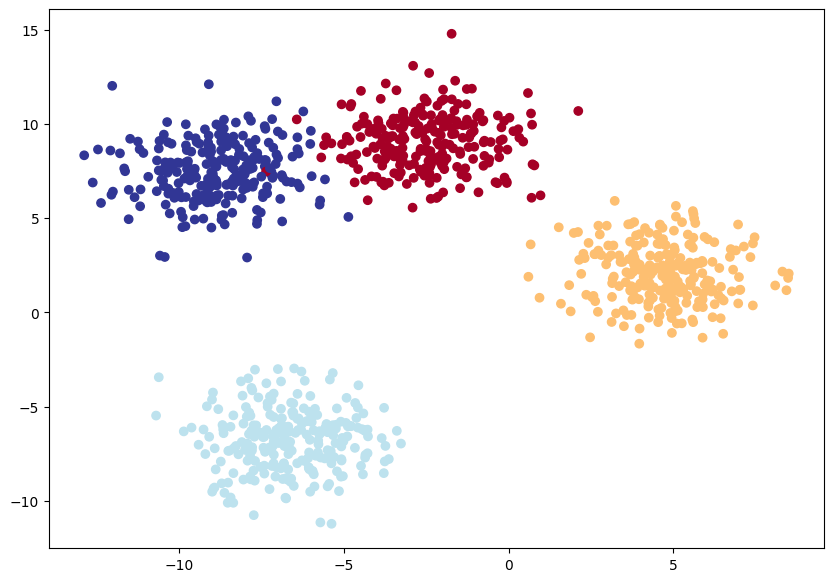

In [ ]:
#should be captilized bc constant
num_classes = 4
num_features = 2
torch.manual_seed(42)

#data — cluster_std makes more variance in blobs & overlap making prob harder if >1
xblob, yblob = make_blobs(n_samples=1000, n_features=num_features, centers=num_classes, cluster_std=1.5, random_state=rand_seed)

#data -> tensor
xblob = torch.from_numpy(xblob).type(torch.float)
yblob = torch.from_numpy(yblob).type(torch.LongTensor)  #This type for CrossEntropy
print(xblob[:5], yblob[:5])

#split
xtrain, xtest, ytrain, ytest = train_test_split(xblob, yblob, test_size=0.2, random_state=rand_seed)

#plotting
plt.figure(figsize=(10, 7))
plt.scatter(xblob[:, 0], xblob[:, 1], c=yblob, cmap=plt.cm.RdYlBu);

In [ ]:
class BlobModel(nn.Module):
  def __init__(self, in2features, out2features, units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=in2features, out_features=units),
        #nn.Relu() if need non-linear ~ would add btw all layers
        nn.Linear(in_features=units, out_features=units),
        nn.Linear(in_features=units, out_features=out2features)
    )
  def forward(self, x):
    return self.linear_layer_stack(x)


In [ ]:
modelb = BlobModel(in2features=num_features, out2features=num_classes, units=8).to(device)
print(modelb)

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)


In [ ]:
loss_fn = nn.CrossEntropyLoss() #bc multi-class
optimizer = torch.optim.SGD(params=modelb.parameters(), lr=0.1)

In [ ]:
untrainedPred = modelb(xtrain.to(device))
untrainedPred[:5], ytest[:5]

(tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
         [ 0.2210, -1.5439,  0.0420,  1.1531],
         [ 2.8698,  0.9143,  3.3169,  1.4027],
         [ 1.9576,  0.3125,  2.2244,  1.1324],
         [ 0.5458, -1.2381,  0.4441,  1.1804]], grad_fn=<SliceBackward0>),
 tensor([1, 3, 2, 1, 0]))

Softmax calculates the probability of it being of a each class rather than in comparision to all other possible classes. (untrainedPred is still logits)

Notice how each row of untrainedPredProbabilties sums up to 1, each of the 4 represents the prob of it being that class, so the highest prob would be what it would be classified as.

In [ ]:
untrainedPredProbabilities = torch.softmax(untrainedPred, dim=1)
untrainedPredProbabilities, torch.sum(untrainedPredProbabilities[0]), torch.argmax(untrainedPredProbabilities[0])

(tensor([[0.1838, 0.3422, 0.1500, 0.3239],
         [0.2199, 0.0377, 0.1839, 0.5586],
         [0.3406, 0.0482, 0.5326, 0.0785],
         ...,
         [0.2106, 0.0444, 0.1712, 0.5738],
         [0.3415, 0.0651, 0.4871, 0.1063],
         [0.3099, 0.0148, 0.3449, 0.3304]], grad_fn=<SoftmaxBackward0>),
 tensor(1., grad_fn=<SumBackward0>),
 tensor(1))

In [ ]:
#Accuracy: classification metric (example)
def accuracy(numTrue, numPrediction):
  correct = torch.eq(numTrue, numPrediction).sum().item()
  #torch.eq true if 2 tensors equal
  #.item() turns the tensor to scalar of tensor's dtype
  accuracyy = (correct/len(numPrediction))*100
  return accuracyy

Training + Testing Loop

In [ ]:
#data to device
epochs = 1000
xtrain, xtest, ytrain, ytest = xtrain.to(device), xtest.to(device), ytrain.to(device), ytest.to(device)

In [ ]:
for epoch in range(epochs):
  modelb.train()

  #Forward pass - model will output raw logit -> turn to prediction probabilities -> labels
  ylogits = modelb(xtrain).squeeze() #squeeze cuz out_features = 1 so 1 val per sample
  ypred = torch.softmax(ylogits, dim=1).argmax(dim=1)

  #Calculate loss/accuracy
  loss = loss_fn(ylogits, ytrain)
  acc = accuracy(ytrain, ypred)

  #Optimizer zero grad - reseting gradients from backpropogation
  optimizer.zero_grad()

  #Loss backward - computes new gradients
  loss.backward()

  #Optimizer Step - updates weights using the gradients
  optimizer.step()

  # -- Testing --
  modelb.eval()
  with torch.inference_mode(): #context manager, turns off model training stuff like gradients so saves memory n speed
    #inference: using trained model to make predictions on new data

    #Forward pass
    testLogits = modelb(xtest).squeeze()
    testPreds = torch.softmax(testLogits, dim=1).argmax(dim=1)

    #Calculate loss/accuracy
    testLoss = loss_fn(testLogits, ytest)
    testAcc = accuracy(ytest, testPreds)

  #printing test results
  if epoch%10==0:
    print(f"Epoch: {epoch} - Loss: {loss:.5f} - Accuracy: {acc:.1f} - Test Loss: {testLoss:.5f} Test Acc: {testAcc:.1f}")


Epoch: 0 - Loss: 1.04324 - Accuracy: 65.5 - Test Loss: 0.57861 Test Acc: 95.5
Epoch: 10 - Loss: 0.14398 - Accuracy: 99.1 - Test Loss: 0.13037 Test Acc: 99.0
Epoch: 20 - Loss: 0.08062 - Accuracy: 99.1 - Test Loss: 0.07216 Test Acc: 99.5
Epoch: 30 - Loss: 0.05924 - Accuracy: 99.1 - Test Loss: 0.05133 Test Acc: 99.5
Epoch: 40 - Loss: 0.04892 - Accuracy: 99.0 - Test Loss: 0.04098 Test Acc: 99.5
Epoch: 50 - Loss: 0.04295 - Accuracy: 99.0 - Test Loss: 0.03486 Test Acc: 99.5
Epoch: 60 - Loss: 0.03910 - Accuracy: 99.0 - Test Loss: 0.03083 Test Acc: 99.5
Epoch: 70 - Loss: 0.03643 - Accuracy: 99.0 - Test Loss: 0.02799 Test Acc: 99.5
Epoch: 80 - Loss: 0.03448 - Accuracy: 99.0 - Test Loss: 0.02587 Test Acc: 99.5
Epoch: 90 - Loss: 0.03300 - Accuracy: 99.1 - Test Loss: 0.02423 Test Acc: 99.5
Epoch: 100 - Loss: 0.03185 - Accuracy: 99.1 - Test Loss: 0.02293 Test Acc: 99.5
Epoch: 110 - Loss: 0.03093 - Accuracy: 99.1 - Test Loss: 0.02186 Test Acc: 99.5
Epoch: 120 - Loss: 0.03017 - Accuracy: 99.1 - Test 

Predictions & Evaluation:

In [ ]:
#Imported from the git dir

# Plot linear data or training and test and predictions (optional)
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    #Plots linear training data and test data and compares predictions.
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    #Plots decision boundaries of model predicting on X in comparison to y. Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())

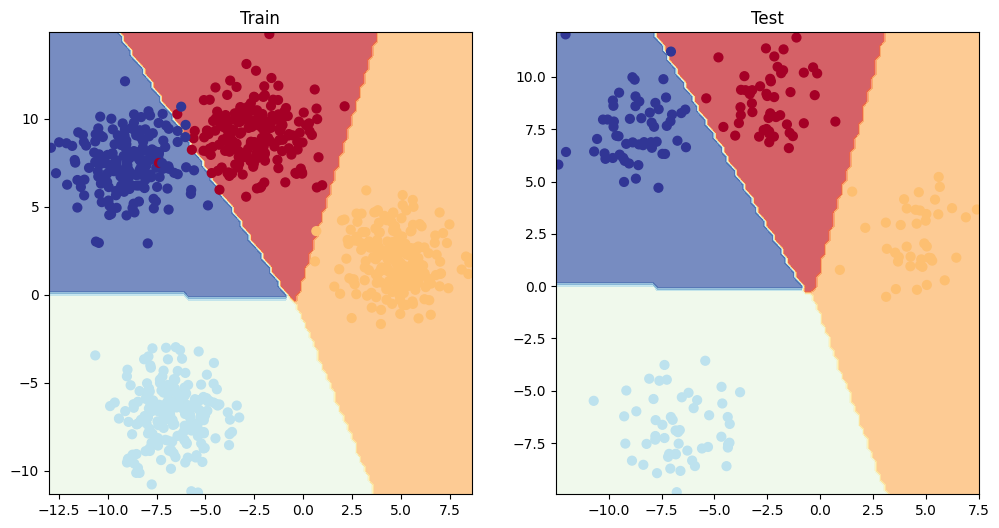

In [ ]:
#Also copied bc lazy

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelb, xtrain, ytrain)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelb, xtest, ytest)

More Classification Evaluation Methods:
*   Accuracy: as implemented or torchmetrics.Accuracy()
*   Precision: Num of true positives over total num of samples
*   Recall: Num of true positives over true positives+false negatives
*   F1-Score: Combines prescision and recall, 1 is good, 0 is bad
*   Confusion Matrix: Compares predicated values and true values in table format
*   Classification Report: Collection of classificatino metrics like recision, recall and F1-score



Improving Model: (previous model is modelling for line not circle)
Techniques:
*   Add layers: aka making your neural network deeper
*   Add hidden units: aka making your neural network wider
*   Fitting for Longer: adding more epochs
*   Changing activation functions: if you find out its a wrong fit
*   Changing learning rate:
*   Change loss function:
*   Use transfer learning: take a pretrained model (kinda cheating)
(Called hyperparameters because all can be changed by hand)

Full 2 Circles Example + Notes:

This model will have 3 nn layers and use ReLU (Recitifed Linear-Unit). ReLU does max(0, x). Using flats and lines with curves can create shapes like circles. Is also a lot faster with alg. ReLU can be 0->infinity but Sigmoid only 0 or 1.
Note: ReLU only affects hidden layers

Sigmoid suffers from vanishing gradient problem: gradients shrink to near zero as they flow through many layers

Binary cross entropy implementations: torch.nn.BCELoss(), torch.nn.BCEWithLogisticsLoss() same as but with sigmoid layer built in
BCEWithLogisticsLoss() is more numerically stable but in more advanced use cases you want to seperate combination fo sigmoid layer and BCELoss()

Alternative decleration of Model (sequential only runs sequentially)

Evaluation Metric: Basically how correct your model is (opposite of loss func)

Logit: Output on raw model before any optimization

Sigmoid Activation Function: Exists in BCEWithLogitsLoss. Sigmoid turns raw logit into something intreperable in this case ie) 0.44 is 44% chance of being classifeid 1. Turns into form of prediction probabilities.
Acutal classification would be prediction labels.

Using predefined in previous lines plot funcs

In [ ]:
#Creating relu and sigmoid for fun
def relu(x: torch.Tensor):
  return max(torch.tensor(0), x)
def rigmoid(x):
  return 1/(1+torch.exp(-x))

In [ ]:
# numSamples = 1000
# x, y = make_circles(numSamples, noise = 0.03, random_state=42)
# print(f"x:\n{x[:5]}")
# print(f"\ny\n{y[:5]}")

# circles = pd.DataFrame({"x1": x[:,0], "x2": x[:,1], "label":y})
# circles.head(10), circles.label.value_counts(), x.shape, y.shape

# xt = torch.from_numpy(x).type(torch.float)
# yt = torch.from_numpy(y).type(torch.float)
# xtrain, xtest, ytrain, ytest = train_test_split(xt, yt, test_size=0.2, random_state=42)
# xtrain[:5], ytrain[:5], xtrain.dtype

# class CircleModelPatel(nn.Module):
#   def __init__(self):
#     super().__init__()
#     self.layer1 = nn.Linear(in_features=2, out_features=10)
#     self.layer2 = nn.Linear(in_features=10, out_features=10)
#     self.layer3 = nn.Linear(in_features=10, out_features=1)
#     self.relu = nn.ReLU()
#   def forward(self, x):
#     return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
# model1 = CircleModelPatel().to(device)
# print(model1)

# model2 = nn.Sequential(nn.Linear(in_features=2, out_features=5), nn.Linear(in_features=5, out_features=1)).to(device)
# print(model2)

#plt.scatter(x=x[:,0], y=x[:,1], c=y, cmap=plt.cm.RdYlBu)

# loss_fn = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.SGD(params=model1.parameters(), lr=0.1)

# def accuracy(numTrue, numPrediction):
#   correct = torch.eq(numTrue, numPrediction).sum().item()
#   #torch.eq true if 2 tensors equal
#   #.item() turns the tensor to scalar of tensor's dtype
#   accuracyy = (correct/len(numPrediction))*100
#   return accuracyy

# logitBridget = model1(xtrain.to(device))
# print(logitBridget[:5])

# logitBridgetSigmoided = torch.sigmoid(logitBridget)
# print(logitBridgetSigmoided[:5])

# predLabel = torch.round(logitBridgetSigmoided)
# print(predLabel[:5])

# torch.manual_seed(42)

# epochs = 1000
# xtrain, xtest, ytrain, ytest = xtrain.to(device), xtest.to(device), ytrain.to(device), ytest.to(device)

# for epoch in range(epochs):
#   model1.train()

#   #Forward pass - model will output raw logit -> turn to prediction probabilities -> labels
#   ylogits = model1(xtrain).squeeze() #squeeze cuz out_features = 1 so 1 val per sample
#   ypred = torch.round(torch.sigmoid(ylogits))

#   #Calculate loss/accuracy
#   loss = loss_fn(ylogits, ytrain) #no need for sigmoid bc BCEWithLogitLoss
#   acc = accuracy(ytrain, ypred)

#   #Optimizer zero grad - reseting gradients from backpropogation
#   optimizer.zero_grad()

#   #Loss backward - computes new gradients
#   loss.backward()

#   #Optimizer Step - updates weights using the gradients
#   optimizer.step()

#   # -- Testing --
#   model1.eval()
#   with torch.inference_mode(): #context manager, turns off model training stuff like gradients so saves memory n speed
#     #inference: using trained model to make predictions on new data

#     #Forward pass
#     testLogits = model1(xtest).squeeze()
#     testPreds = torch.round(torch.sigmoid(testLogits))

#     #Calculate loss/accuracy
#     testLoss = loss_fn(testLogits, ytest)
#     testAcc = accuracy(ytest, testPreds)

#   #printing test results
#   if epoch%10==0:
#     print(f"Epoch: {epoch} - Loss: {loss:.5f} - Accuracy: {acc:.1f} - Test Loss: {testLoss:.5f} Test Acc: {testAcc:.1f}")

# # Plot decision boundaries for training and test sets
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.title("Train")
# plot_decision_boundary(model1, xtrain, ytrain)
# plt.subplot(1, 2, 2)
# plt.title("Test")
# plot_decision_boundary(model1, xtest, ytest)
